# (노트) 로지스틱에서 MSE를 사용하지 않는 이유
> 작성완료

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [딥러닝]

### About this doc 

`-` 2021년 1학기 전북대학교 데이터과학 강의노트

### 관점1 

`-` 우도함수에 근거한 loss는 MSE가 아니라 크로스 엔트로피다. 

### 관점2

`-` MSE로 손실함수를 정의하면 손실함수가 convex가 아니게 된다. 

`-` 논의를 단순화 하기 위하여 

$$loss=\sum_{i=1}^{n}(y_i-\hat{y_i})^2=\sum_{i=1}^{n}\big(y_i -\frac{e^{x_i\beta}}{e^{x_i\beta}+1} \big)^2$$

를 가정하자. 

`-` 손실함수를 $\frac{\partial}{\partial \beta}$로 두번 미분하여 항상 양수가 나와야 한다. 

`-` 예비계산: 

$\frac{\partial}{\partial \beta} \hat{y_i}
=\frac{e^{x_i\beta}x_i(e^{x_i\beta}+1)-e^{x_i\beta}e^{x_i\beta}x_i}{(e^{x_i\beta}+1)^2}\\
=\frac{e^{x_i\beta}(e^{x_i\beta}+1)-e^{x_i\beta}e^{x_i\beta}}{(e^{x_i\beta}+1)^2}x_i\\
=\frac{e^{x_i\beta}}{(e^{x_i\beta}+1)^2}x_i\\
=\hat{y_i}(1-\hat{y_i})x_i$

`-` 한번미분: 

$\frac{\partial}{\partial \beta}loss=\sum_{i=1}^{n} -2(y_i-\hat{y_i})\hat{y_i}(1-\hat{y_i})x_i\\
=\sum_{i=1}^{n} -2(y_i-\hat{y_i})\hat{y_i}(1-\hat{y_i})x_i\\
=\sum_{i=1}^{n}-2\big(\hat{y_i}^3-\hat{y_i}^2(1+y_i)+\hat{y_i}y_i\big)x_i$

`–` 두번미분: 

$\big(\frac{\partial}{\partial \beta}\big)^2 loss=\sum_{i=1}^{n}-2\big(3\hat{y_i}^2-2\hat{y_i}(1+y_i)+y_i\big)x_i\hat{y_i}(1-\hat{y_i})x_i$

`–` $\hat{y_i}(1-\hat{y_i})>0$ 이고 $x_i^2>0$이므로 

$$3\hat{y_i}^2-2\hat{y_i}(1+y_i)+y_i$$

임의 부호만 따지면 된다. 어떠한 조합 $(y_i,\hat{y_i})$에 대하여서도 위의 식이 항상 음수이면 된다. 하지만 $y_i=0$일때 $\hat{y_i}\approx 1$이면  위의 부호가 양수이므로 두번 미분한것이 항상 양수인것은 아니다. 따라서 컨벡스가 아니다. 

### 관점3

#### 예제1 

`-` 로지스틱 시그모이드를 활성화 함수로 사용하는 하나의 노드를 생각하자. 이 노드는 입력 $x$와 출력 $y$에 대하여 

$$y =\frac{e^{\beta_1 x+\beta_0}}{1+e^{\beta_1 x+\beta_0}}$$

와 같은 동작을 할 것이다. 

`-` 이제 $(x_i,y_i)=(1.5,0)$인 자료를 받았다고 하자. 

`-` 그렇다면 우리는 하나의 자료를 적합시키기 위한 $\beta_0,\beta_1$의 값을 구해야 할것이다. 

`-` 즉 손실함수를 정의하고 그 손실함수의 미분값을 바탕으로 적절한 $\beta_0,\beta_1$를 반복하여 찾아나가야 한다. 

`-` 손실함수를 아래와 같이 정의하였다고 하자. 

$$loss(\beta_0,\beta_1)=\left(y_i-\frac{e^{\beta_1x_i+\beta_0}}{1+e^{\beta_1x_i+\beta_0}}\right)^2$$

In [5]:
import numpy as np 

def loss(β0,β1):
    yi=0
    xi=1.5
    yihat=np.exp(β1*xi +β0)/(1+np.exp(β1*xi+β0))
    return (yi-yihat)**2

`-` 초기값 $(\beta_0,\beta_1)=(0.5,0.4)$를 사용한뒤에 경사하강법을 활용하여 $(\beta_0,\beta_1)$를 조금씩 수정하는 전략을 취하자. 

우선 초기값 $(\beta_0,\beta_1)=(0.5,0.4)$가 그럴듯한 값인지 살펴보자. (우연히 찍어서 좋은 값이 나올수도 있으니까) 

In [6]:
np.exp(0.4*1.5 +0.5)/(1+np.exp(0.4*1.5+0.5))

0.7502601055951176

실제로는 $y_i=0$이므로 계산된 신경망의 출력 $0.75$와 상당한 차이가 있어보인다. 

따라서 $(\beta_0,\beta_1)=(0.5,0.4)$는 많은 개선이 필요해 보인다. 

이제 경사하강법을 사용하여 $(\beta_0,\beta_1)$을 업데이트 하는 방법을 생각해보자. 

- $\frac{\partial }{\partial \beta_0}loss(\beta_0,\beta_1)=?$
- $\frac{\partial }{\partial \beta_1}loss(\beta_0,\beta_1)=?$

를 계산한뒤에 값을 비교하고 유리한 방향으로 움직여보자. 

손 미분하기 귀찮으니까 적당히 작은 $h$에 대하여

- $\frac{loss(\beta_0+h,\beta_1)-loss(\beta_0,\beta_1)}{h}$

- $\frac{loss(\beta_0,\beta_1+h)-loss(\beta_0,\beta_1)}{h}$ 

를 계산해줄 계산기를 구현하자. 

In [7]:
def grdnt(loss,β0,β1):
    h=1e-4
    Δ0=loss(β0+h,β1)-loss(β0,β1)
    Δ1=loss(β0,β1+h)-loss(β0,β1)
    return Δ0/h, Δ1/h

In [8]:
grdnt(loss,0.5,0.4)

(0.28114876562401747, 0.42172050396582783)

기울기가 양수이므로 반대 방향으로 움직여야 한다. 

즉 $\beta_0, \beta_1$모두 감소시켜야함. 예를들면 $(\beta_0,\beta_1)$를 $(0.5,0.4) \to (0.45,0.35)$ 이런식으로 loss를 줄일 수 있다. 

In [9]:
loss(0.5,0.4)

0.562890226047597

In [10]:
loss(0.45,0.35)

0.5272429660113416

정말로 손실이 줄어들었다. 

그리고 신경망의 출력도 조사해보니 

In [11]:
np.exp(0.4*1.5 +0.5)/(1+np.exp(0.4*1.5+0.5))

0.7502601055951176

In [12]:
np.exp(0.35*1.5 +0.45)/(1+np.exp(0.35*1.5+0.45))

0.7261149812607791

확실히 $(\beta_0,\beta_1)=(0.5,0.4)$일 경우보다 $(\beta_0,\beta_1)=(0.45,0.35)$일 경우가 좀 더 $y_i=0$이라는 관측치에 가까워졌다. 

`-` 이번에는 초기값 $(\beta_0,\beta_1)=(3,1.9)$에서 시작하는 경사하강법을 생각해보자. 

신경망의 초기 출력은 

In [13]:
np.exp(1.9*1.5 +3)/(1+np.exp(1.9*1.5+3))

0.9971283708442996

엄청나게 잘못되었다. $y_i$의 실제값은 $0$인데 초기가중치로 인한 신경망의 출력은 거의 $0.997$이다. 경사하강법으로 인한 개선이 많이 필요해 보인다. 

개선을 시켜보자. 

In [14]:
grdnt(loss,3,1.9)

(0.005710037608297469, 0.008564844138359007)

이번에도 둘다 기울기가 양수이므로 $(\beta_0,\beta_1)$의 값은 모두 줄여야 한다. 

그런데 지금 문제는 방향이 아니라 크기이다. 분명히 두번째 초기값 $(\beta_0,\beta_1)=(3,1.9)$은 첫번째 초기값 $(\beta_0,\beta_1)=(0.5,0.4)$보다 더 나쁜 초기값이다. 그런데 미분한 결과를 보면 두번째 초기값의 경우가 미분계수의 크기가 훨씬 작다. 

확률적 경사하강법은 미분계수의 크기와 비례하여 학습속도가 결정되는데 이대로라면 안 좋은 초기값에서 `오히려` 학습속도가 훨씬 느려지게 된다. 

이는 상식적이지 않다. 왜냐하면 오차가 클수록 큰 폭으로 수정해야하고 오차가 작을수록 조금씩 수정해야 효율적인데 지금은 그렇지 않기 때문이다. 

`-` 손실함수를 수정하여 보자. 

$$loss(\beta_0,\beta_1)= -\big( y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \big) $$

수정된 손실함수를 구현하여보자. 

In [15]:
def loss2(β0,β1):
    yi=0
    xi=1.5
    yihat=np.exp(β1*xi +β0)/(1+np.exp(β1*xi+β0))
    return - (yi*np.log(yihat)+(1-yi)*np.log(1-yihat))

이제 수정된 손실함수에 대하여 두 초기값을 활용한 확률적 경사하강법을 다시 생각해보자. 

In [16]:
# 첫번째 초기값, MSE 
grdnt(loss,0.5,0.4)

(0.28114876562401747, 0.42172050396582783)

In [17]:
# 두번째 초기값, MSE 
grdnt(loss,3,1.9)

(0.005710037608297469, 0.008564844138359007)

In [18]:
# 첫번째 초기값, 크로스엔트로피
grdnt(loss2,0.5,0.4)

(0.7502694739369709, 1.1254112369774028)

In [19]:
# 두번째 초기값, 크로스엔트로피
grdnt(loss2,3,1.9)

(0.9971285138732355, 1.495692878403787)

크로스엔트로피의 경우 오차가 더 큰 두번째 초기값에 더 큰 패널티를 줬다. 

`-` 왜 이러한 현상이 생기는가? 

활성화 함수의 모양을 생각해보자. 

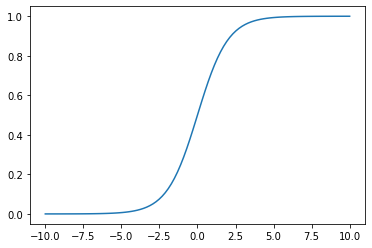

In [26]:
import matplotlib.pyplot as plt 
x=np.linspace(-10,10,100)
y=np.exp(x)/ (np.exp(x)+1)
plt.plot(x,y)

생각해보니까 함수모양이 위와 같이 생겼으므로 $\hat{y}_i\approx 0$ 이거나 $\hat{y}_i \approx 1$ 에서는 $\beta_0,\beta_1$를 변화시켜봐야 변화폭이 미미하다. 

원래 아래와 같은 활성화 함수를 고려하려고 했었는데

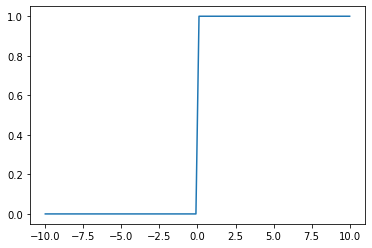

In [27]:
plt.plot(x,x>0)

그나마 미분이 가능하고 모양도 얼추 비슷한 활성화 함수를 고르다 보니 이렇게 된것이다. 

***딜레마***

모형은 데이터를 설명할 수 있어야 하고 학습가능한 형태이어야 한다. 계단모양의 활성화 함수는 데이터를 잘 표현할 수 있을지는 몰라도 그레디언트 기반의 방법으로 학습이 불가능하다. 시그모이드 활성화 함수는 데이터도 표현할수 있고 학습이 가능한 형태이다. 그런데 $\hat{y}_i\approx 0$ 이거나 $\hat{y}_i \approx 1$에서 변화폭이 너무 적어 학습이 더딘 점이 있다. 

그렇다고 $\hat{y}_i\approx 0$ 혹은 $\hat{y}_i \approx 1$에서 기울기를 확 주는 활성화 함수를 고려하여 학습속도를 올리기도 애매하다. 두 가지 점에서 애매한데 첫번째는 계단모양의 활성화 함수와 점점 멀어진다는 점이다. 

두번째 포인트가 더 크리티컬하다. 두 번째 포인트는 $\hat{y}_i \approx 0$ 혹은 $\hat{y}_i \approx 1$에서 학습속도를 확 올리는 전략이 맞냐는 것이다. 사람마음이 간사한것이 실제 $y_i$의 값에 따라서 어쩔때는 학습속도를 올리고싶을때가 있고 그렇지 않을때가 있다. 

- 상황1: 실제 $y_i=0$ 인데, $\hat{y}_i\approx 0$ 인 경우 $\to$ 지금 좋은데? $(\beta_0,\beta_1)$의 update 폭이 적었으면 좋겠는데? 
- 상황2: 실제 $y_i=0$ 인데, $\hat{y}_i\approx 1$ 인 경우 $\to$ 지금 너무 안좋은데? $(\beta_0,\beta_1)$의 update 폭이 아주 컸으면 좋겠는데? (그냥 차라리 랜덤으로 다시 뽑아서 여기를 탈출하는게 낫겠다 라는 생각이 들정도로) 

결국 $y_i=0$ 인데, $\hat{y}_i\approx 1$ 인 상황 (혹은 반대상황) 이 문제가 되는것인데 마음같아서는 이러한 상황에서 매우 가혹한 벌점을 부여하고 싶다는 것이다. 

***딜레마해결***

이런면에서 크로스엔트로피와 시그모이드는 매우 궁합이 잘맞는편이다. 크로스엔트로피의 손실은 

$$-\big( y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \big) $$

와 같이 생겼고 $n$개의 샘플에 대하여서는 

$$-\sum_{i=1}^{n}\big( y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \big) $$

와 같이 생겼는데 $y_i=0$ 일때 $\hat{y}_i\approx 1$인 상황에서는 

$$(1-y_i)\log (1-\hat{y}_i)$$

가 음의 무한대로 터지고 반대의 상황에서는 

$$y_i\log \hat{y}_i$$

가 음의 무한대로 터져서 시그모이드함수에 의해 학습이 느려지는 단점이 완벽하게 보안된다. 

`-` 다시 한번 우도함수의 위대함이 느껴지는 순간임